# analisi random forest

In [2]:
# Data Processing
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score, cross_val_predict, StratifiedShuffleSplit, StratifiedKFold
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

RANDOM_SEED = 42
from pathlib import Path

data_root_candidates = [
    Path("balduf_anon_march_2026"),
    Path("../balduf_anon_march_2026"),
    Path("datasets/balduf_anon_march_2026"),
    Path("../datasets/balduf_anon_march_2026"),
]
data_root = next((path for path in data_root_candidates if path.exists()), None)
if data_root is None:
    raise FileNotFoundError(f"Nessuna cartella dati trovata tra: {data_root_candidates}")



## Tempo di vita degli account positivi, per bucket (00, 0p, p0, pp)

Boxplot del tempo trascorso tra la creazione dell'account (`created_at`, dal pool grezzo dei positivi) e l'evento di takedown registrato (`event_time`, da `positive_blocks_analysis`), suddiviso per i quattro macro-bucket di esposizione:
- **00**: `post_bucket_index == 0` e `follow_10d_bucket_index == 0`
- **0p**: `post_bucket_index == 0` e `follow_10d_bucket_index > 0`
- **p0**: `post_bucket_index > 0` e `follow_10d_bucket_index == 0`
- **pp**: `post_bucket_index > 0` e `follow_10d_bucket_index > 0`

Account positivi con created_at disponibile: 36735
        count       mean    median
bucket                            
00      20205   1.747585  0.000081
0p       4579   9.795944  1.847813
p0       4378   5.049990  1.012575
pp       7573  12.503611  1.935394


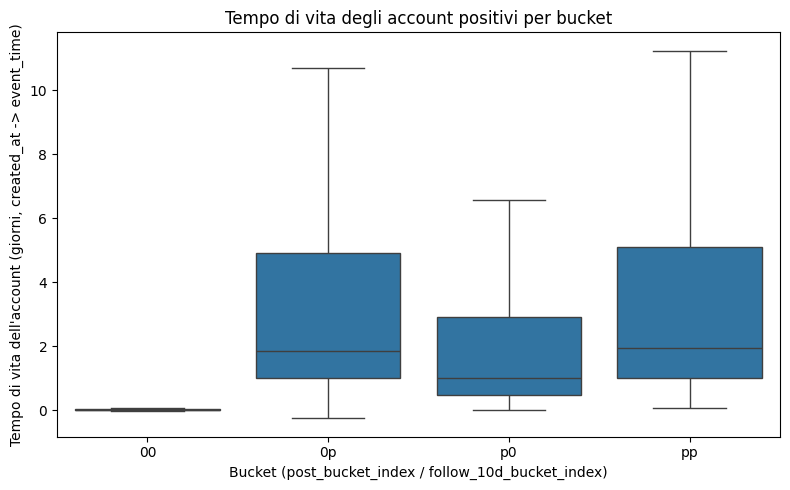

In [3]:


raw_positive_path = data_root / "raw_positive_pool_mar2026_created_anon.parquet"
positive_blocks_path = data_root / "positive_blocks_analysis_10d_mar2026_v3_anon.parquet"

# created_at è tz-aware (UTC), event_time è tz-naive: converto created_at "AT TIME ZONE 'UTC'"
# per allineare i due timestamp prima della sottrazione, esattamente come farebbe tz_localize(None) in pandas
lifetime_query = f"""
SELECT
    pb.post_bucket_index,
    pb.follow_10d_bucket_index,
    date_diff('second', rp.created_at AT TIME ZONE 'UTC', pb.event_time) / 86400.0 AS lifetime_days,
    CASE
        WHEN pb.post_bucket_index = 0 AND pb.follow_10d_bucket_index = 0 THEN '00'
        WHEN pb.post_bucket_index = 0 AND pb.follow_10d_bucket_index > 0 THEN '0p'
        WHEN pb.post_bucket_index > 0 AND pb.follow_10d_bucket_index = 0 THEN 'p0'
        ELSE 'pp'
    END AS bucket
FROM read_parquet('{positive_blocks_path}') pb
JOIN read_parquet('{raw_positive_path}') rp USING (did_anon)
WHERE rp.created_at IS NOT NULL
"""

lifetime_df = duckdb.sql(lifetime_query).df()

bucket_order = ["00", "0p", "p0", "pp"]

print("Account positivi con created_at disponibile:", len(lifetime_df))
print(lifetime_df.groupby("bucket")["lifetime_days"].agg(["count", "mean", "median"]).loc[bucket_order])

plt.figure(figsize=(8, 5))
sns.boxplot(data=lifetime_df, x="bucket", y="lifetime_days", order=bucket_order, showfliers=False)
plt.xlabel("Bucket (post_bucket_index / follow_10d_bucket_index)")
plt.ylabel("Tempo di vita dell'account (giorni, created_at -> event_time)")
plt.title("Tempo di vita degli account positivi per bucket")
plt.tight_layout()
plt.show()


In [4]:

positive_path = data_root / "rf_1000_pool/positive_rf_pool_by_exposure_bucket.parquet"
negative_path = data_root / "rf_1000_pool/negative_rf_pool_by_exposure_bucket.parquet"

pos = pd.read_parquet(positive_path)
neg = pd.read_parquet(negative_path)

pos["target"] = 1
neg["target"] = 0

df = pd.concat([pos, neg], ignore_index=True)

id_cols = [
    "did_anon",
    "event_time",
    "event_day",
    "window_start",
    "window_end"
    
]

exposure_cols = [
    "post_bucket_index",
    "follow_10d_bucket_index",
    "exposure_bucket_index",
    "n_posts_10d",
    "incoming_follows_10d"
]

non_numeric_cols = [
    "has_block_day_0",
    "has_block_day_1",
    "has_block_day_2",
    "has_block_day_3",
    "has_block_day_4",
    "has_block_day_5",
    "has_block_day_6",
    "has_block_day_7",
    "has_block_day_8",
    "has_block_day_9",
    "has_block_10d"
]
target_col = "target"

exclude_cols = id_cols + exposure_cols + [target_col] + non_numeric_cols

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols]
y = df[target_col]

print("\n FEATURES USED ")
print(feature_cols)




 FEATURES USED 
['n_blocks_received_10d', 'n_unique_blockers_10d', 'n_blocks_0_1d', 'n_blocks_1_3d', 'n_blocks_3_7d', 'n_blocks_7_10d', 'n_blocks_day_0', 'n_blocks_day_1', 'n_blocks_day_2', 'n_blocks_day_3', 'n_blocks_day_4', 'n_blocks_day_5', 'n_blocks_day_6', 'n_blocks_day_7', 'n_blocks_day_8', 'n_blocks_day_9', 'n_unique_blockers_day_0', 'n_unique_blockers_day_1', 'n_unique_blockers_day_2', 'n_unique_blockers_day_3', 'n_unique_blockers_day_4', 'n_unique_blockers_day_5', 'n_unique_blockers_day_6', 'n_unique_blockers_day_7', 'n_unique_blockers_day_8', 'n_unique_blockers_day_9', 'log1p_blocks_received_10d', 'log1p_unique_blockers_10d']


In [5]:
#analisi 1
# TRAIN / TEST SPLIT
from sklearn.metrics import classification_report, f1_score


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,     #mantenere nel training e nel test la stessa proporzione tra positivi e negativi presente nel dataset completo.
)

print("Dataset completo:")
print("X:", X.shape)  #restituisce numero di righe, numero di colonne
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:")
print(y_train.value_counts())

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=500,           #num di alberi creati, più è alto più il modello è potente ma anche più lento da addestrare. 500 è un buon compromesso per dataset di medie dimensioni
    max_depth=None,             #non imponi una profondità massima agli alberi
    min_samples_leaf=5,         #ogni foglia finale dell’albero deve contenere almeno 5 osservazioni, questo parametro serve quindi a evitare regole troppo specifiche e instabili
    random_state=RANDOM_SEED,   #Fissando il seed, ogni volta che lanci lo script ottieni lo stesso modello e gli stessi risultati. È fondamentale per poter riprodurre l’analisi
    n_jobs=-1,                  #Dice a scikit-learn di utilizzare tutti i processori disponibili per costruire gli alberi più rapidamente.
    class_weight=None,          #Indica che positivi e negativi hanno lo stesso peso nel training. Nel mio caso essendo un campione bilanciato va bene.
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# predizioni out-of-fold (cross-validate) sul training set, usate per le metriche
y_pred = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1)
y_proba = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

rf.fit(X_train, y_train)  # fit finale sull'intero training set, usato solo per la feature importance

# EVALUATION

print("\n METRICS (cross-validated su X_train) ")
print("Accuracy :", accuracy_score(y_train, y_pred)) #Su tutti gli account del training set, quanti sono stati classificati correttamente?
print("Precision:", precision_score(y_train, y_pred)) #Tra gli account che il modello ha classificato come positivi, quanti sono effettivamente positivi?
print("Recall   :", recall_score(y_train, y_pred)) #Tra tutti gli account effettivamente positivi, quanti sono stati classificati correttamente dal modello?
print("F1       :", f1_score(y_train, y_pred)) #Media armonica tra precision e recall, è una metrica più bilanciata quando si vuole tenere conto sia dei falsi positivi che dei falsi negativi. Un buon modello dovrebbe avere un F1 score alto, idealmente vicino a 1.
                                              #F1 combina precision e recall in un solo valore.
print("\n CONFUSION MATRIX ")
print(confusion_matrix(y_train, y_pred)) #mostra concretamente quanti account il modello ha classificato bene o male : [[TN  FP][FN  TP]]

print("\n CLASSIFICATION REPORT ")
print(classification_report(y_train, y_pred))

# FEATURE IMPORTANCE

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\n FEATURE IMPORTANCE ")
print(importances)

Dataset completo:
X: (1910, 28)
y: (1910,)

Training set:
X_train: (1337, 28)
y_train:
target
1    669
0    668
Name: count, dtype: int64

Test set:
X_test: (573, 28)
y_test:
target
0    287
1    286
Name: count, dtype: int64
CV F1 mean: 0.3713177974575449 | CV F1 std: 0.040399248126113084

 METRICS (cross-validated su X_train) 
Accuracy : 0.5953627524308153
Precision: 0.8333333333333334
Recall   : 0.23916292974588937
F1       : 0.3716608594657375

 CONFUSION MATRIX 
[[636  32]
 [509 160]]

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.56      0.95      0.70       668
           1       0.83      0.24      0.37       669

    accuracy                           0.60      1337
   macro avg       0.69      0.60      0.54      1337
weighted avg       0.69      0.60      0.54      1337


 FEATURE IMPORTANCE 
                      feature  importance
6              n_blocks_day_0    0.154431
2               n_blocks_0_1d    0.149363
16   

##### Quando segnala un account come positivo, spesso ha ragione. Ma segnala come positivi solo una piccola parte dei veri account con takedown.

### Proviamo a cambiare il modello, alcune features sono sovrapposte
#### ad esempio 'blocks' e 'unique_blockers' , 'n_blocks_day_0' e 'n_blocks_0_1'

In [6]:
#analisi 2
overlap_columns = [
    "n_blocks_received_10d",
    "n_blocks_0_1d",
    "n_blocks_1_3d",
    "n_blocks_3_7d",
    "n_blocks_7_10d",
    "n_blocks_day_0",
    "n_blocks_day_1",
    "n_blocks_day_2",
    "n_blocks_day_3",
    "n_blocks_day_4",
    "n_blocks_day_5",
    "n_blocks_day_6",
    "n_blocks_day_7",
    "n_blocks_day_8",
    "n_blocks_day_9",
    "log1p_blocks_received_10d",
    "log1p_unique_blockers_10d"
]

exclude_cols_1 = exclude_cols + overlap_columns

feature_cols_1 = [
    col for col in df.columns
    if col not in exclude_cols_1
]

feature_cols_2 = [col for col in feature_cols_1 if col != "sampling_group"]

X = df[feature_cols_2]
y = df[target_col]

print("\n FEATURES USED ")
print(feature_cols_1)

# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,     #mantenere nel training e nel test la stessa proporzione tra positivi e negativi presente nel dataset completo.
)

print("Dataset completo:")
print("X:", X.shape)  #restituisce numero di righe, numero di colonne
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:")
print(y_train.value_counts())

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=500,           #num di alberi creati, più è alto più il modello è potente ma anche più lento da addestrare. 500 è un buon compromesso per dataset di medie dimensioni
    max_depth=None,             #non imponi una profondità massima agli alberi
    min_samples_leaf=5,         #ogni foglia finale dell’albero deve contenere almeno 5 osservazioni, questo parametro serve quindi a evitare regole troppo specifiche e instabili
    random_state=RANDOM_SEED,   #Fissando il seed, ogni volta che lanci lo script ottieni lo stesso modello e gli stessi risultati. È fondamentale per poter riprodurre l’analisi
    n_jobs=-1,                  #Dice a scikit-learn di utilizzare tutti i processori disponibili per costruire gli alberi più rapidamente.
    class_weight=None,          #Indica che positivi e negativi hanno lo stesso peso nel training. Nel mio caso essendo un campione bilanciato va bene.
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# predizioni out-of-fold (cross-validate) sul training set, usate per le metriche
y_pred = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1)
y_proba = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

rf.fit(X_train, y_train)  # fit finale sull'intero training set, usato solo per la feature importance

# EVALUATION

print("\n METRICS (cross-validated su X_train) ")
print("Accuracy :", accuracy_score(y_train, y_pred)) #Su tutti gli account del training set, quanti sono stati classificati correttamente?
print("Precision:", precision_score(y_train, y_pred)) #Tra gli account che il modello ha classificato come positivi, quanti sono effettivamente positivi?
print("Recall   :", recall_score(y_train, y_pred)) #Tra tutti gli account effettivamente positivi, quanti sono stati classificati correttamente dal modello?
print("F1       :", f1_score(y_train, y_pred)) #Media armonica tra precision e recall, è una metrica più bilanciata quando si vuole tenere conto sia dei falsi positivi che dei falsi negativi. Un buon modello dovrebbe avere un F1 score alto, idealmente vicino a 1.
                                              #F1 combina precision e recall in un solo valore.
print("\n CONFUSION MATRIX ")
print(confusion_matrix(y_train, y_pred)) #mostra concretamente quanti account il modello ha classificato bene o male : [[TN  FP][FN  TP]]

print("\n CLASSIFICATION REPORT ")
print(classification_report(y_train, y_pred))

# FEATURE IMPORTANCE

importances = pd.DataFrame({
    "feature": feature_cols_2,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\n FEATURE IMPORTANCE ")
print(importances)



 FEATURES USED 
['n_unique_blockers_10d', 'n_unique_blockers_day_0', 'n_unique_blockers_day_1', 'n_unique_blockers_day_2', 'n_unique_blockers_day_3', 'n_unique_blockers_day_4', 'n_unique_blockers_day_5', 'n_unique_blockers_day_6', 'n_unique_blockers_day_7', 'n_unique_blockers_day_8', 'n_unique_blockers_day_9']
Dataset completo:
X: (1910, 11)
y: (1910,)

Training set:
X_train: (1337, 11)
y_train:
target
1    669
0    668
Name: count, dtype: int64

Test set:
X_test: (573, 11)
y_test:
target
0    287
1    286
Name: count, dtype: int64


CV F1 mean: 0.38192648199584617 | CV F1 std: 0.04176896670368845

 METRICS (cross-validated su X_train) 
Accuracy : 0.5961106955871354
Precision: 0.8146341463414634
Recall   : 0.24962630792227206
F1       : 0.38215102974828374

 CONFUSION MATRIX 
[[630  38]
 [502 167]]

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.56      0.94      0.70       668
           1       0.81      0.25      0.38       669

    accuracy                           0.60      1337
   macro avg       0.69      0.60      0.54      1337
weighted avg       0.69      0.60      0.54      1337


 FEATURE IMPORTANCE 
                    feature  importance
1   n_unique_blockers_day_0    0.441513
0     n_unique_blockers_10d    0.320999
2   n_unique_blockers_day_1    0.086548
3   n_unique_blockers_day_2    0.063887
4   n_unique_blockers_day_3    0.032631
5   n_unique_blockers_day_4    0.021225
10  n_unique_blockers_day_9    0.012457
6   n_unique_blockers_day_5    0.010

## Allarghiamo la pool di positivi e negativi

In [7]:

positive_path = data_root / "rf_10000_pool/positive_10000_pool.parquet"
negative_path = data_root / "rf_10000_pool/negative_10000_pool.parquet"

pos = pd.read_parquet(positive_path)
neg = pd.read_parquet(negative_path)

pos["target"] = 1
neg["target"] = 0

df = pd.concat([pos, neg], ignore_index=True)

X = df[feature_cols_1]
Y = df[target_col]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=Y,     #mantenere nel training e nel test la stessa proporzione tra positivi e negativi presente nel dataset completo.
)

print("Dataset completo:")
print("X:", X.shape)  #restituisce numero di righe, numero di colonne
print("Y:", Y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("Y_train:")
print(Y_train.value_counts())

print("\nTest set:")
print("X_test:", X_test.shape)
print("Y_test:")
print(Y_test.value_counts())

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=1000,           #num di alberi creati, più è alto più il modello è potente ma anche più lento da addestrare. 500 è un buon compromesso per dataset di medie dimensioni
    max_depth=None,             #non imponi una profondità massima agli alberi
    min_samples_leaf=5,         #ogni foglia finale dell’albero deve contenere almeno 5 osservazioni, questo parametro serve quindi a evitare regole troppo specifiche e instabili
    random_state=RANDOM_SEED,   #Fissando il seed, ogni volta che lanci lo script ottieni lo stesso modello e gli stessi risultati. È fondamentale per poter riprodurre l’analisi
    n_jobs=-1,                  #Dice a scikit-learn di utilizzare tutti i processori disponibili per costruire gli alberi più rapidamente.
    class_weight=None,          #Indica che positivi e negativi hanno lo stesso peso nel training. Nel mio caso essendo un campione bilanciato va bene.
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf, X_train, Y_train, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# predizioni out-of-fold (cross-validate) sul training set, usate per le metriche
Y_pred = cross_val_predict(rf, X_train, Y_train, cv=cv, n_jobs=-1)
Y_proba = cross_val_predict(rf, X_train, Y_train, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

rf.fit(X_train, Y_train)  # fit finale sull'intero training set, usato solo per la feature importance

# EVALUATION

print("\n METRICS (cross-validated su X_train) ")
print("Accuracy :", accuracy_score(Y_train, Y_pred)) #Su tutti gli account del training set, quanti sono stati classificati correttamente?
print("Precision:", precision_score(Y_train, Y_pred)) #Tra gli account che il modello ha classificato come positivi, quanti sono effettivamente positivi?
print("Recall   :", recall_score(Y_train, Y_pred)) #Tra tutti gli account effettivamente positivi, quanti sono stati classificati correttamente dal modello?
print("F1       :", f1_score(Y_train, Y_pred)) #Media armonica tra precision e recall, è una metrica più bilanciata quando si vuole tenere conto sia dei falsi positivi che dei falsi negativi. Un buon modello dovrebbe avere un F1 score alto, idealmente vicino a 1.
                                              #F1 combina precision e recall in un solo valore.
print("\n CONFUSION MATRIX ")
print(confusion_matrix(Y_train, Y_pred)) #mostra concretamente quanti account il modello ha classificato bene o male : [[TN  FP][FN  TP]]

print("\n CLASSIFICATION REPORT ")
print(classification_report(Y_train, Y_pred))

# FEATURE IMPORTANCE

importances = pd.DataFrame({
    "feature": feature_cols_1,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\n FEATURE IMPORTANCE ")
print(importances)

Dataset completo:
X: (19556, 11)
Y: (19556,)

Training set:
X_train: (13689, 11)
Y_train:
target
1    6845
0    6844
Name: count, dtype: int64

Test set:
X_test: (5867, 11)
Y_test:
target
0    2934
1    2933
Name: count, dtype: int64
CV F1 mean: 0.3769614266198454 | CV F1 std: 0.01396407373423772

 METRICS (cross-validated su X_train) 
Accuracy : 0.6002629848783695
Precision: 0.8540484785972151
Recall   : 0.24192841490138786
F1       : 0.3770491803278688

 CONFUSION MATRIX 
[[6561  283]
 [5189 1656]]

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.56      0.96      0.71      6844
           1       0.85      0.24      0.38      6845

    accuracy                           0.60     13689
   macro avg       0.71      0.60      0.54     13689
weighted avg       0.71      0.60      0.54     13689


 FEATURE IMPORTANCE 
                    feature  importance
1   n_unique_blockers_day_0    0.463785
0     n_unique_blockers_10d    0.300315


## ora provo a non considerare il bucket 00

In [8]:
positive_path = data_root / "rf_10000_no00_01_pool/positive_10000_no00_01_pool.parquet"
negative_path = data_root / "rf_10000_no00_01_pool/negative_10000_no00_01_pool.parquet"

pos = pd.read_parquet(positive_path)
neg = pd.read_parquet(negative_path)

pos["target"] = 1
neg["target"] = 0

df = pd.concat([pos, neg], ignore_index=True)

X = df[feature_cols_1]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,     #mantenere nel training e nel test la stessa proporzione tra positivi e negativi presente nel dataset completo.
)

print("Dataset completo:")
print("X:", X.shape)  #restituisce numero di righe, numero di colonne
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:")
print(y_train.value_counts())

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=1000,           #num di alberi creati, più è alto più il modello è potente ma anche più lento da addestrare. 500 è un buon compromesso per dataset di medie dimensioni
    max_depth=None,             #non imponi una profondità massima agli alberi
    min_samples_leaf=5,         #ogni foglia finale dell’albero deve contenere almeno 5 osservazioni, questo parametro serve quindi a evitare regole troppo specifiche e instabili
    random_state=RANDOM_SEED,   #Fissando il seed, ogni volta che lanci lo script ottieni lo stesso modello e gli stessi risultati. È fondamentale per poter riprodurre l’analisi
    n_jobs=-1,                  #Dice a scikit-learn di utilizzare tutti i processori disponibili per costruire gli alberi più rapidamente.
    class_weight=None,          #Indica che positivi e negativi hanno lo stesso peso nel training. Nel mio caso essendo un campione bilanciato va bene.
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# predizioni out-of-fold (cross-validate) sul training set, usate per le metriche
y_pred = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1)
y_proba = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

rf.fit(X_train, y_train)  # fit finale sull'intero training set, usato solo per la feature importance

# EVALUATION

print("\n METRICS (cross-validated su X_train) ")
print("Accuracy :", accuracy_score(y_train, y_pred)) #Su tutti gli account del training set, quanti sono stati classificati correttamente?
print("Precision:", precision_score(y_train, y_pred)) #Tra gli account che il modello ha classificato come positivi, quanti sono effettivamente positivi?
print("Recall   :", recall_score(y_train, y_pred)) #Tra tutti gli account effettivamente positivi, quanti sono stati classificati correttamente dal modello?
print("F1       :", f1_score(y_train, y_pred)) #Media armonica tra precision e recall, è una metrica più bilanciata quando si vuole tenere conto sia dei falsi positivi che dei falsi negativi. Un buon modello dovrebbe avere un F1 score alto, idealmente vicino a 1.
                                              #F1 combina precision e recall in un solo valore.
print("\n CONFUSION MATRIX ")
print(confusion_matrix(y_train, y_pred)) #mostra concretamente quanti account il modello ha classificato bene o male : [[TN  FP][FN  TP]]

print("\n CLASSIFICATION REPORT ")
print(classification_report(y_train, y_pred))

# FEATURE IMPORTANCE

importances = pd.DataFrame({
    "feature": feature_cols_1,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\n FEATURE IMPORTANCE ")
print(importances)

Dataset completo:
X: (19456, 11)
y: (19456,)

Training set:
X_train: (13619, 11)
y_train:
target
1    6810
0    6809
Name: count, dtype: int64

Test set:
X_test: (5837, 11)
y_test:
target
0    2919
1    2918
Name: count, dtype: int64
CV F1 mean: 0.7279545496062202 | CV F1 std: 0.010738521478289045

 METRICS (cross-validated su X_train) 
Accuracy : 0.7648138629855349
Precision: 0.8626583551176352
Recall   : 0.6299559471365639
F1       : 0.728167699227701

 CONFUSION MATRIX 
[[6126  683]
 [2520 4290]]

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.71      0.90      0.79      6809
           1       0.86      0.63      0.73      6810

    accuracy                           0.76     13619
   macro avg       0.79      0.76      0.76     13619
weighted avg       0.79      0.76      0.76     13619


 FEATURE IMPORTANCE 
                    feature  importance
1   n_unique_blockers_day_0    0.432268
0     n_unique_blockers_10d    0.333442
2

# Analisi su pool con 00, 0p, p0, pp bilanciati. 10000

In [9]:
positive_path = data_root / "rf_10000_balanced_4groups_pool/positive_10000_4groups_pool.parquet"
negative_path = data_root / "rf_10000_balanced_4groups_pool/negative_10000_4groups_pool.parquet"

pos = pd.read_parquet(positive_path)
neg = pd.read_parquet(negative_path)

pos["target"] = 1
neg["target"] = 0

df = pd.concat([pos, neg], ignore_index=True)

macro_group = np.where(
    (df["post_bucket_index"] == 0) & (df["follow_10d_bucket_index"] == 0),
    "00",
    np.where(
        (df["post_bucket_index"] == 0) & (df["follow_10d_bucket_index"] > 0),
        "0p",
        np.where(
            (df["post_bucket_index"] > 0) & (df["follow_10d_bucket_index"] == 0),
            "p0",
            "pp"
        )
    )
)

X = df[feature_cols_1]
y = df[target_col]

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    macro_group,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,     #mantenere nel training e nel test la stessa proporzione tra positivi e negativi presente nel dataset completo.
)

print("Dataset completo:")
print("X:", X.shape)  #restituisce numero di righe, numero di colonne
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:")
print(y_train.value_counts())

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

print("\nTraining set by group:")
print(pd.Series(group_train).value_counts().sort_index())

# RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=1000,           #num di alberi creati, più è alto più il modello è potente ma anche più lento da addestrare. 500 è un buon compromesso per dataset di medie dimensioni
    max_depth=None,             #non imponi una profondità massima agli alberi
    min_samples_leaf=5,         #ogni foglia finale dell’albero deve contenere almeno 5 osservazioni, questo parametro serve quindi a evitare regole troppo specifiche e instabili
    random_state=RANDOM_SEED,   #Fissando il seed, ogni volta che lanci lo script ottieni lo stesso modello e gli stessi risultati. È fondamentale per poter riprodurre l’analisi
    n_jobs=-1,                  #Dice a scikit-learn di utilizzare tutti i processori disponibili per costruire gli alberi più rapidamente.
    class_weight=None,          #Indica che positivi e negativi hanno lo stesso peso nel training. Nel mio caso essendo un campione bilanciato va bene.
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# predizioni out-of-fold (cross-validate) sul training set, usate per le metriche
y_pred = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1)
y_proba = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1, method="predict_proba")[:, 1]

rf.fit(X_train, y_train)  # fit finale sull'intero training set, usato solo per la feature importance

# EVALUATION

print("\n METRICS (cross-validated su X_train) ")
print("Accuracy :", accuracy_score(y_train, y_pred)) #Su tutti gli account del training set, quanti sono stati classificati correttamente?
print("Precision:", precision_score(y_train, y_pred)) #Tra gli account che il modello ha classificato come positivi, quanti sono effettivamente positivi?
print("Recall   :", recall_score(y_train, y_pred)) #Tra tutti gli account effettivamente positivi, quanti sono stati classificati correttamente dal modello?
print("F1       :", f1_score(y_train, y_pred)) #Media armonica tra precision e recall, è una metrica più bilanciata quando si vuole tenere conto sia dei falsi positivi che dei falsi negativi. Un buon modello dovrebbe avere un F1 score alto, idealmente vicino a 1.
                                              #F1 combina precision e recall in un solo valore.
print("\n CONFUSION MATRIX ")
print(confusion_matrix(y_train, y_pred)) #mostra concretamente quanti account il modello ha classificato bene o male : [[TN  FP][FN  TP]]

print("\n CLASSIFICATION REPORT ")
print(classification_report(y_train, y_pred))

results_by_group = pd.DataFrame({
    "group": group_train,
    "y_true": y_train.to_numpy(),
    "y_pred": y_pred,
})

group_metrics = []

for group in ["00", "0p", "p0", "pp"]:
    g = results_by_group[results_by_group["group"] == group]
    group_metrics.append({
        "group": group,
        "n": len(g),
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        "f1": f1_score(g["y_true"], g["y_pred"], zero_division=0),
    })

group_metrics = pd.DataFrame(group_metrics)

print("\n METRICS BY GROUP ")
print(group_metrics)

# FEATURE IMPORTANCE

importances = pd.DataFrame({
    "feature": feature_cols_1,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\n FEATURE IMPORTANCE ")
print(importances)

Dataset completo:
X: (20000, 11)
y: (20000,)

Training set:
X_train: (14000, 11)
y_train:
target
0    7000
1    7000
Name: count, dtype: int64

Test set:
X_test: (6000, 11)
y_test:
target
0    3000
1    3000
Name: count, dtype: int64

Training set by group:
00    3521
0p    3513
p0    3461
pp    3505
Name: count, dtype: int64
CV F1 mean: 0.5630812513372935 | CV F1 std: 0.014159248222944733

 METRICS (cross-validated su X_train) 
Accuracy : 0.6744285714285714
Precision: 0.8555620267909144
Recall   : 0.4197142857142857
F1       : 0.5631589035844355

 CONFUSION MATRIX 
[[6504  496]
 [4062 2938]]

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.62      0.93      0.74      7000
           1       0.86      0.42      0.56      7000

    accuracy                           0.67     14000
   macro avg       0.74      0.67      0.65     14000
weighted avg       0.74      0.67      0.65     14000


 METRICS BY GROUP 
  group     n  accuracy  pre

# Bilanciati, no 00, Max numero di positivi 

In [12]:
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, roc_auc_score

data_root_candidates = [
    Path("balduf_anon_march_2026"),
    Path("../balduf_anon_march_2026"),
    Path("datasets/balduf_anon_march_2026"),
    Path("../datasets/balduf_anon_march_2026"),
]
data_root = next((path for path in data_root_candidates if path.exists()), None)
if data_root is None:
    raise FileNotFoundError(f"Nessuna cartella dati trovata tra: {data_root_candidates}")

positive_path = data_root / "rf_max_pool_no_00/positive_max_pool_no_00.parquet"
negative_path = data_root / "rf_max_pool_no_00/negative_max_pool_no_00.parquet"

pos = pd.read_parquet(positive_path)
neg = pd.read_parquet(negative_path)

pos["target"] = 1
neg["target"] = 0

df = pd.concat([pos, neg], ignore_index=True)

df["macro_group"] = np.where(
    (df["post_bucket_index"] == 0) & (df["follow_10d_bucket_index"] == 0),
    "00",
    np.where(
        (df["post_bucket_index"] == 0) & (df["follow_10d_bucket_index"] > 0),
        "0p",
        np.where(
            (df["post_bucket_index"] > 0) & (df["follow_10d_bucket_index"] == 0),
            "p0",
            "pp"
        )
    )
)

print("Distribuzione pool per macro-bucket e target:")
display(
    df.groupby(["macro_group", "target"])
      .size()
      .unstack(fill_value=0)
      .reindex(["00", "0p", "p0", "pp"], fill_value=0)
)

X = df[feature_cols_1]
y = df[target_col]
macro_group = df["macro_group"]

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    macro_group,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("\nFEATURES USED")
print(feature_cols_1)

print("\nDataset completo:")
print("X:", X.shape)
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:")
print(y_train.value_counts())

print("\nTest set held-out:")
print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

print("\nTraining set by macro-group:")
print(pd.Series(group_train).value_counts().reindex(["00", "0p", "p0", "pp"], fill_value=0))

print("\nTest set held-out by macro-group:")
print(pd.Series(group_test).value_counts().reindex(["00", "0p", "p0", "pp"], fill_value=0))

# Controllo leakage per DID: non cambia la validazione originale, ma segnala
# se lo stesso account compare in training/test o in fold diversi della CV.
did_candidates = ["did_anon", "did", "account_did", "subject_did", "repo", "actor_did"]
did_col = next((col for col in did_candidates if col in df.columns), None)

if did_col is None:
    print("\nDID LEAKAGE CHECK")
    print("Nessuna colonna DID riconosciuta tra:", did_candidates)
else:
    train_dids = df.loc[X_train.index, did_col].dropna().astype(str)
    test_dids = df.loc[X_test.index, did_col].dropna().astype(str)
    train_test_overlap = sorted(set(train_dids) & set(test_dids))

    print("\nDID LEAKAGE CHECK")
    print("Colonna DID usata:", did_col)
    print("DID distinti nel training:", train_dids.nunique())
    print("DID distinti nel test held-out:", test_dids.nunique())
    print("DID presenti sia in training sia in test:", len(train_test_overlap))
    if train_test_overlap:
        print("ATTENZIONE: potenziale leakage train/test. Esempi:", train_test_overlap[:10])
    else:
        print("Nessun DID in comune tra training e test.")

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight=None,
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

if did_col is not None:
    fold_leakage = []
    train_dids_aligned = df.loc[X_train.index, did_col].reset_index(drop=True).astype(str)
    for fold_id, (fit_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        fit_dids = set(train_dids_aligned.iloc[fit_idx].dropna())
        val_dids = set(train_dids_aligned.iloc[val_idx].dropna())
        overlap = fit_dids & val_dids
        if overlap:
            fold_leakage.append({
                "fold": fold_id,
                "overlap_dids": len(overlap),
                "examples": sorted(overlap)[:5],
            })

    print("\nDID overlap tra fold CV sul training:")
    if fold_leakage:
        print("ATTENZIONE: almeno un DID compare sia nel fit sia nella validation fold.")
        display(pd.DataFrame(fold_leakage))
    else:
        print("Nessun DID condiviso tra fit e validation fold nella CV stratificata.")

cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("\nCV OUT-OF-FOLD SU TRAINING")
print("CV F1 mean:", cv_scores.mean(), "| CV F1 std:", cv_scores.std())

# Predizioni out-of-fold sul training set, usate solo per le metriche CV.
y_pred_cv = cross_val_predict(rf, X_train, y_train, cv=cv, n_jobs=-1)
y_proba_cv = cross_val_predict(
    rf,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1,
    method="predict_proba"
)[:, 1]

print("\nMETRICHE CV OUT-OF-FOLD SUL TRAINING")
print("Accuracy :", accuracy_score(y_train, y_pred_cv))
print("Precision:", precision_score(y_train, y_pred_cv, zero_division=0))
print("Recall   :", recall_score(y_train, y_pred_cv, zero_division=0))
print("F1       :", f1_score(y_train, y_pred_cv, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_train, y_proba_cv))

print("\nCONFUSION MATRIX CV OUT-OF-FOLD SUL TRAINING")
print(confusion_matrix(y_train, y_pred_cv))

print("\nCLASSIFICATION REPORT CV OUT-OF-FOLD SUL TRAINING")
print(classification_report(y_train, y_pred_cv, zero_division=0))

results_by_group_cv = pd.DataFrame({
    "group": pd.Series(group_train).reset_index(drop=True),
    "y_true": y_train.reset_index(drop=True),
    "y_pred": y_pred_cv,
    "y_proba": y_proba_cv,
})

def metrics_by_macro_group(results):
    group_summary = []
    group_class_reports = []

    for group in ["00", "0p", "p0", "pp"]:
        g = results[results["group"] == group]

        if len(g) == 0:
            group_summary.append({
                "group": group,
                "n": 0,
                "n_0": 0,
                "n_1": 0,
                "accuracy": np.nan,
                "roc_auc": np.nan,
            })
            continue

        group_summary.append({
            "group": group,
            "n": len(g),
            "n_0": int((g["y_true"] == 0).sum()),
            "n_1": int((g["y_true"] == 1).sum()),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "roc_auc": roc_auc_score(g["y_true"], g["y_proba"]) if g["y_true"].nunique() == 2 else np.nan,
        })

        report = classification_report(
            g["y_true"],
            g["y_pred"],
            labels=[0, 1],
            output_dict=True,
            zero_division=0
        )

        for cls in ["0", "1"]:
            group_class_reports.append({
                "group": group,
                "class": int(cls),
                "precision": report[cls]["precision"],
                "recall": report[cls]["recall"],
                "f1": report[cls]["f1-score"],
                "support": int(report[cls]["support"]),
            })

    return pd.DataFrame(group_summary), pd.DataFrame(group_class_reports)

group_summary_cv, group_class_reports_cv = metrics_by_macro_group(results_by_group_cv)

print("\nMETRICHE CV OUT-OF-FOLD PER MACRO-GRUPPO")
display(group_summary_cv)

print("\nMETRICHE CV OUT-OF-FOLD PER MACRO-GRUPPO E CLASSE (0 / 1)")
display(group_class_reports_cv.sort_values(["group", "class"]))

# Fit finale sull'intero training set, poi valutazione vera sul test held-out.
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_proba_test = rf.predict_proba(X_test)[:, 1]

print("\nMETRICHE FINALI HELD-OUT SUL TEST SET")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_test, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_test, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_test))

print("\nCONFUSION MATRIX HELD-OUT SUL TEST SET")
print(confusion_matrix(y_test, y_pred_test))

print("\nCLASSIFICATION REPORT HELD-OUT SUL TEST SET")
print(classification_report(y_test, y_pred_test, zero_division=0))

results_by_group_test = pd.DataFrame({
    "group": pd.Series(group_test).reset_index(drop=True),
    "y_true": y_test.reset_index(drop=True),
    "y_pred": y_pred_test,
    "y_proba": y_proba_test,
})

group_summary_test, group_class_reports_test = metrics_by_macro_group(results_by_group_test)

print("\nMETRICHE HELD-OUT PER MACRO-GRUPPO")
display(group_summary_test)

print("\nMETRICHE HELD-OUT PER MACRO-GRUPPO E CLASSE (0 / 1)")
display(group_class_reports_test.sort_values(["group", "class"]))

# Persist final metrics as a generated local artifact.
# The JSON is intentionally not tracked; rerun this notebook to regenerate it.
import json


def _json_clean(value):
    if isinstance(value, dict):
        return {str(k): _json_clean(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_json_clean(v) for v in value]
    if isinstance(value, tuple):
        return [_json_clean(v) for v in value]
    if isinstance(value, pd.DataFrame):
        return _json_clean(value.to_dict(orient="records"))
    if isinstance(value, pd.Series):
        return _json_clean(value.to_dict())
    if isinstance(value, np.ndarray):
        return _json_clean(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)
    if pd.isna(value) if not isinstance(value, (str, bytes, list, tuple, dict)) else False:
        return None
    return value

metrics = {
    "dataset": {
        "X": list(X.shape),
        "y": list(y.shape),
        "train_X": list(X_train.shape),
        "test_X": list(X_test.shape),
        "train_y_counts": y_train.value_counts().sort_index().to_dict(),
        "test_y_counts": y_test.value_counts().sort_index().to_dict(),
        "train_group_counts": pd.Series(group_train).value_counts().reindex(["00", "0p", "p0", "pp"], fill_value=0).to_dict(),
        "test_group_counts": pd.Series(group_test).value_counts().reindex(["00", "0p", "p0", "pp"], fill_value=0).to_dict(),
    },
    "features": list(feature_cols_1),
    "cv": {
        "f1_mean": cv_scores.mean(),
        "f1_std": cv_scores.std(),
        "accuracy": accuracy_score(y_train, y_pred_cv),
        "precision": precision_score(y_train, y_pred_cv, zero_division=0),
        "recall": recall_score(y_train, y_pred_cv, zero_division=0),
        "f1": f1_score(y_train, y_pred_cv, zero_division=0),
        "roc_auc": roc_auc_score(y_train, y_proba_cv),
        "confusion_matrix": confusion_matrix(y_train, y_pred_cv),
        "classification_report": classification_report(y_train, y_pred_cv, zero_division=0),
        "group_summary": group_summary_cv,
        "group_classes": group_class_reports_cv,
    },
    "test": {
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_test),
        "confusion_matrix": confusion_matrix(y_test, y_pred_test),
        "classification_report": classification_report(y_test, y_pred_test, zero_division=0),
        "group_summary": group_summary_test,
        "group_classes": group_class_reports_test,
    },
    "did_leakage": {
        "did_column": did_col if "did_col" in locals() else None,
        "train_test_overlap": len(train_test_overlap) if "train_test_overlap" in locals() else None,
        "cv_fold_overlaps": fold_leakage if "fold_leakage" in locals() else None,
    },
}

metrics_dir = Path("analysis") if Path("analysis").exists() else Path(".")
metrics_path = metrics_dir / "rf_main_heldout_metrics.json"
metrics_path.write_text(
    json.dumps(_json_clean(metrics), indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"Saved generated metrics to {metrics_path}")



Distribuzione pool per macro-bucket e target:
target          0     1
macro_group
00              0     0
0p           4775  4775
p0           4775  4775
pp           4775  4775

FEATURES USED
['n_unique_blockers_10d', 'n_unique_blockers_day_0', 'n_unique_blockers_day_1', 'n_unique_blockers_day_2', 'n_unique_blockers_day_3', 'n_unique_blockers_day_4', 'n_unique_blockers_day_5', 'n_unique_blockers_day_6', 'n_unique_blockers_day_7', 'n_unique_blockers_day_8', 'n_unique_blockers_day_9']

Dataset completo:
X: (28650, 11)
y: (28650,)

Training set:
X_train: (20055, 11)
y_train:
target
0    10027
1    10028

Test set held-out:
X_test: (8595, 11)
y_test:
target
0    4298
1    4297

Training set by macro-group:
00       0
0p    6656
p0    6768
pp    6631

Test set held-out by macro-group:
00       0
0p    2894
p0    2782
pp    2919

DID LEAKAGE CHECK
Colonna DID usata: did_anon
DID distinti nel training: 20055
DID distinti nel test held-out: 8595
DID presenti sia in training sia in test: 0
Nes